<a href="https://colab.research.google.com/github/danishsuryarirta-create/UAS_Bengkel_Koding/blob/main/UAS_Churn_Prediction_A11202314873.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# UAS Bengkel Koding Data Science

# Danish Suryarirta Kusuma Yudha
# A11.2023.14873

# Prediksi Churn Pelanggan — Sales & Marketing Customer Dataset

---
## 📋 Struktur Notebook
1. **EDA** — Eksplorasi & Validasi Data
2. **Direct Modeling** — Baseline tanpa preprocessing
3. **Modeling dengan Preprocessing** — Data bersih + encoding + scaling + SMOTE
4. **Hyperparameter Tuning + Feature Selection** — Optimasi model terbaik
---

## 📦 Import Library

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

!pip install imblearn
from imblearn.over_sampling import SMOTE
import joblib

print('✅ Semua library berhasil di-import!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 8.7 MB/s eta 0:00:00
✅ Semua library berhasil di-import!


---
# BAGIAN 1 — EDA (Exploratory Data Analysis)
> **Tujuan:** Memahami struktur, kualitas, dan pola data sebelum masuk ke pemodelan.

### 1.1 Load Dataset

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Shape dataset : {df.shape}')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Shape dataset : (15000, 30)
Jumlah baris  : 15,000
Jumlah kolom  : 30


### 1.2 Tampilkan 5 Baris Pertama

In [3]:
# menampilkan 5 baris pertama dari DataFrame
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1.3 Informasi Dataset

In [4]:
# menampilkan ringkasan singkat (informasi) dari DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

### 1.4 Statistik Deskriptif

In [5]:
# menampilkan statistik deskriptif dari semua kolom (numerik dan kategorikal) dalam DataFrame df, lalu mentranspos hasilnya agar lebih mudah dibaca.
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,15000.0,NaN,NaN,NaN,17500.5,4330.271354,10001.0,13750.75,17500.5,21250.25,25000.0
gender,14262,3,Male,6844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,13800.0,NaN,NaN,NaN,35.203913,10.334384,-4.0,28.0,35.0,42.0,95.0
country,15000,5,Germany,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,15000,7,London,2236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,15000,1000,2024-09-20 00:00:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,15000,800,2025-01-17 00:00:00,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,15000,5,Organic,3055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,15000,3,Tablet,5043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,15000,2,Monthly,7666,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.5 Persentase Missing Value
> **Insight:** Kolom `coupon_code` memiliki ~40% missing value. Secara logis, nilai kosong berarti pelanggan *tidak menggunakan kupon*, bukan data yang hilang secara acak. Maka kolom ini akan diubah menjadi fitur biner `has_coupon`. Kolom `age`, `total_spent`, dan `satisfaction_score` akan diimputasi dengan median, sedangkan `gender` dengan modus.

                    Missing Count  Missing %
coupon_code                  6133      40.89
age                          1200       8.00
total_spent                  1050       7.00
gender                        738       4.92
satisfaction_score            702       4.68


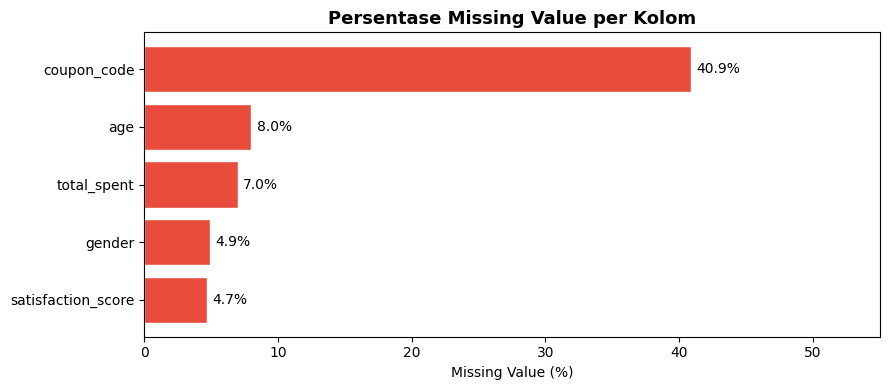

In [6]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#e74c3c', edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in missing_df['Missing %']], padding=4, fontsize=10)
ax.set_xlabel('Missing Value (%)')
ax.set_title('Persentase Missing Value per Kolom', fontsize=13, fontweight='bold')
ax.set_xlim(0, 55)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.6 Distribusi Variabel Target (Churn)
> **Insight:** Dataset mengalami **class imbalance** — kelas churn (1) hanya sekitar 15.3%. Kondisi ini harus ditangani agar model tidak bias memprediksi kelas mayoritas. Pada tahap preprocessing akan digunakan **SMOTE** untuk menyeimbangkan kelas.

Distribusi Churn:
  Tidak Churn (0): 12,702 (84.7%)
  Churn (1): 2,298 (15.3%)


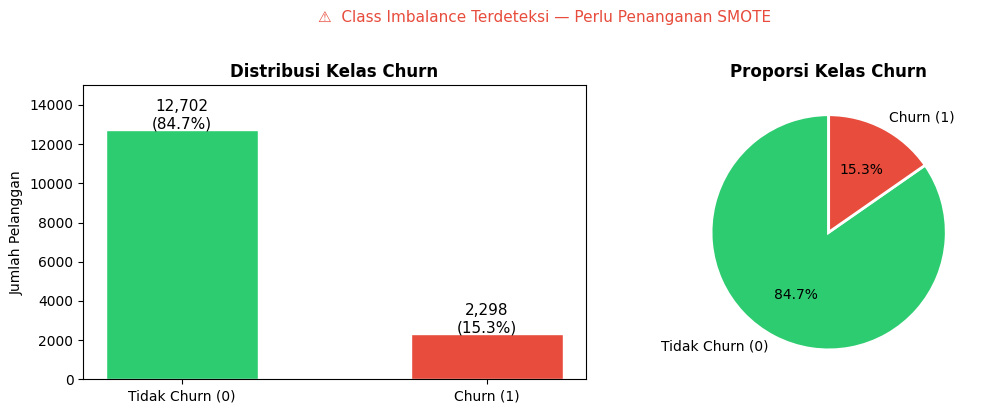

In [7]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print('Distribusi Churn:')
for k, v in churn_counts.items():
    label = 'Churn' if k == 1 else 'Tidak Churn'
    print(f'  {label} ({k}): {v:,} ({churn_pct[k]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_counts.values,
            color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({churn_pct.values[i]:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Distribusi Kelas Churn', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, 15000)

axes[1].pie(churn_counts.values, labels=['Tidak Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=12, fontweight='bold')

plt.suptitle('⚠️  Class Imbalance Terdeteksi — Perlu Penanganan SMOTE',
             fontsize=11, color='#e74c3c', y=1.02)
plt.tight_layout()
plt.show()

### 1.7 Heatmap Korelasi Fitur Numerik
> **Insight:** Korelasi dilihat untuk mengidentifikasi fitur yang berpotensi redundan atau sangat berpengaruh terhadap `churn`.

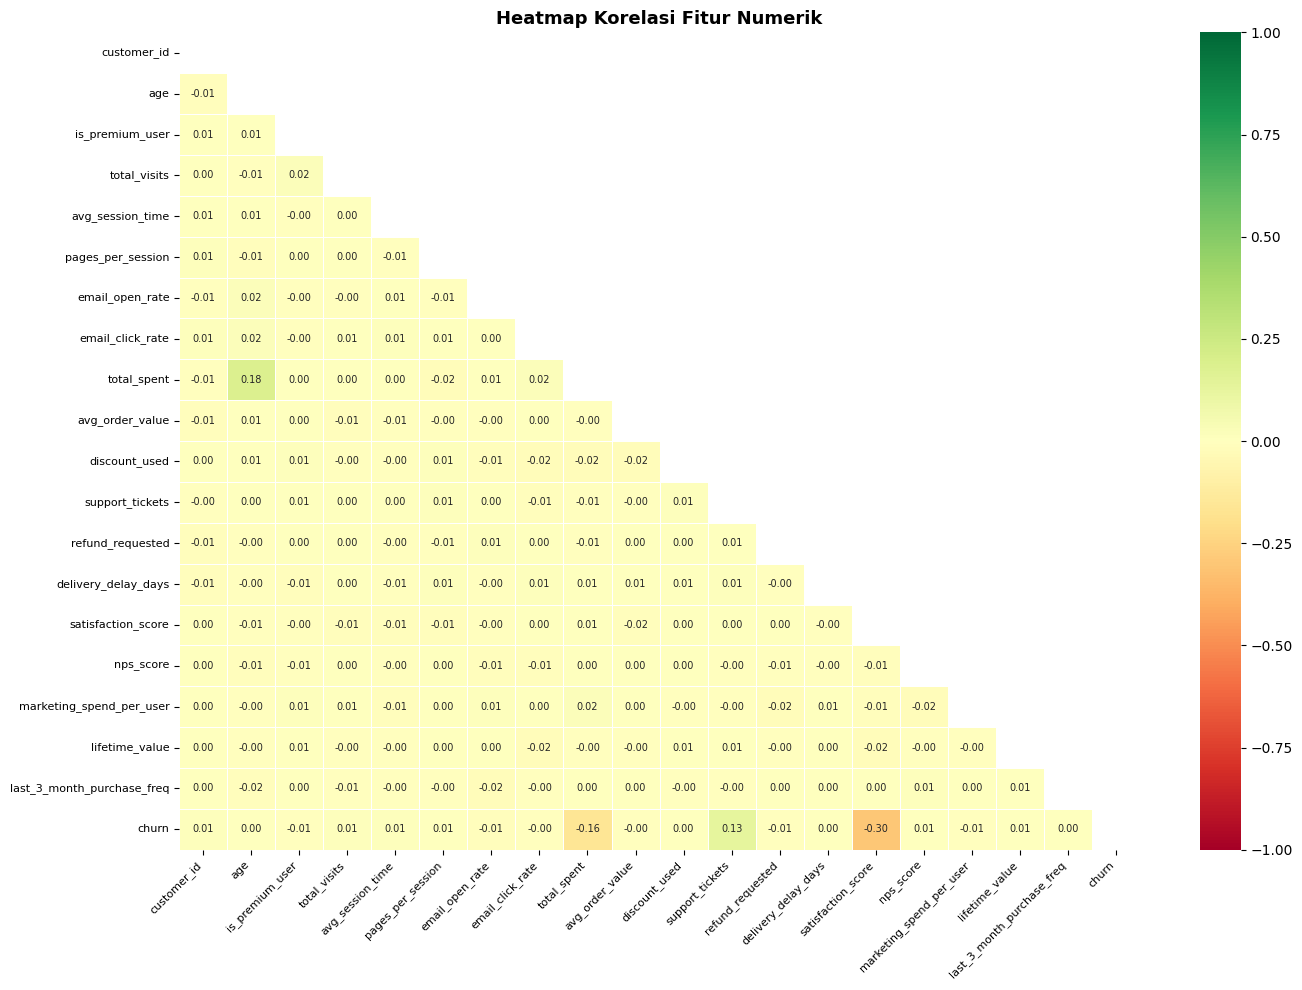


🎯 Korelasi terhadap variabel Churn (urut absolute):
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
customer_id                 0.012208
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250


In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1, center=0)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('\n🎯 Korelasi terhadap variabel Churn (urut absolute):')
print(corr['churn'].drop('churn').abs().sort_values(ascending=False).head(10).to_string())

### 1.8 Distribusi Fitur Numerik Berdasarkan Status Churn

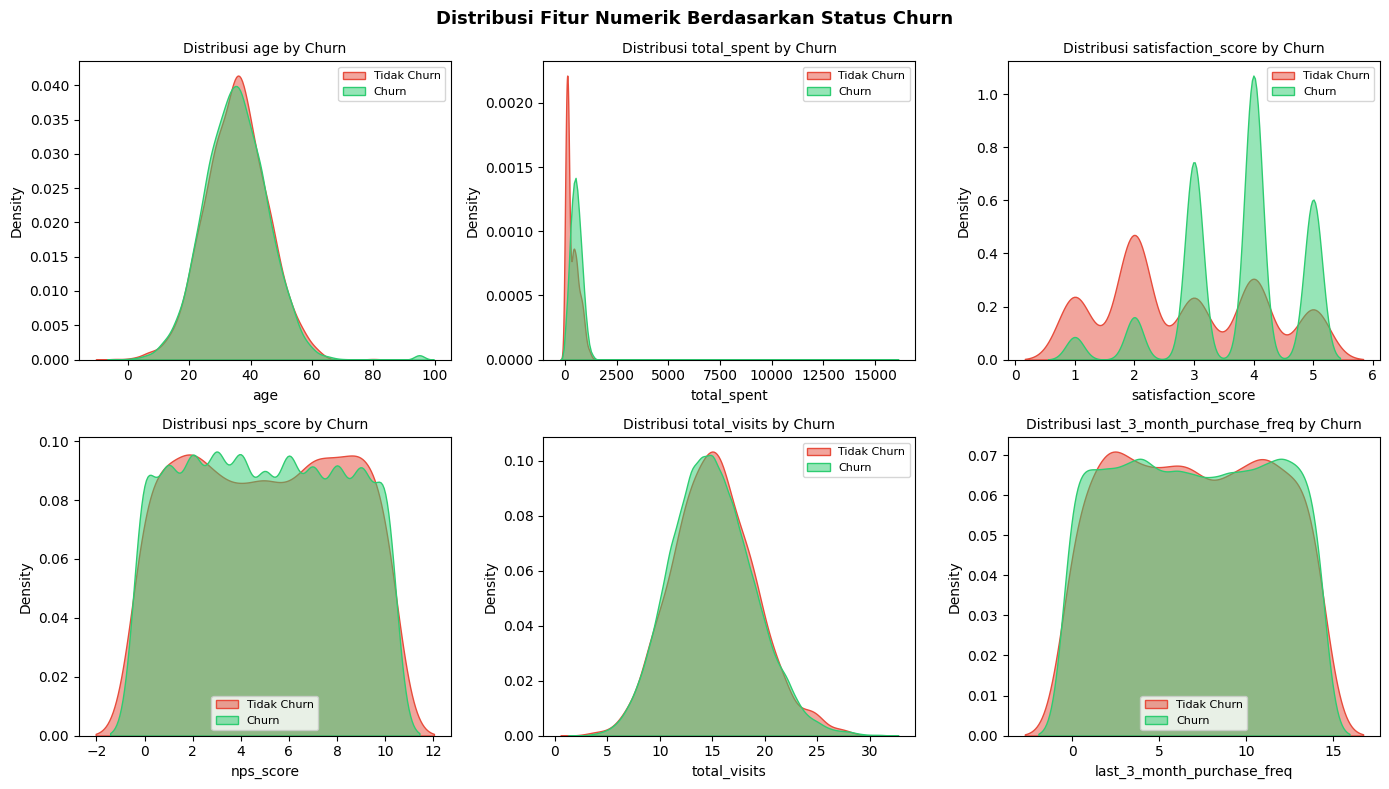

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ['age', 'total_spent', 'satisfaction_score',
             'nps_score', 'total_visits', 'last_3_month_purchase_freq']
palette = {0: '#2ecc71', 1: '#e74c3c'}

for ax, col in zip(axes.flatten(), plot_cols):
    sns.kdeplot(data=df, x=col, hue='churn', fill=True,
                palette=palette, alpha=0.5, ax=ax, common_norm=False)
    ax.set_title(f'Distribusi {col} by Churn', fontsize=10)
    ax.legend(['Tidak Churn', 'Churn'], fontsize=8)

plt.suptitle('Distribusi Fitur Numerik Berdasarkan Status Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# BAGIAN 2 — DIRECT MODELING (Baseline)
> **Tujuan:** Melatih model tanpa preprocessing apapun untuk mendapatkan baseline performa. Hanya kolom numerik yang dipakai karena model tidak bisa menerima string mentah. Missing value diisi median secara minimal agar model bisa berjalan.

### 2.1 Persiapan Data — Direct

In [10]:
# Drop kolom non-numerik dan ID — tidak bisa digunakan langsung oleh model
drop_cols_direct = ['customer_id', 'gender', 'country', 'city', 'signup_date',
                    'last_purchase_date', 'acquisition_channel', 'device_type',
                    'subscription_type', 'coupon_code', 'payment_method']

df_direct = df.drop(columns=drop_cols_direct)

# Isi missing value numerik dengan median (minimal agar model bisa berjalan)
df_direct = df_direct.fillna(df_direct.median(numeric_only=True))

X_dir = df_direct.drop(columns=['churn'])
y_dir = df_direct['churn']

print(f'Fitur yang digunakan : {X_dir.shape[1]} kolom')
print(f'Kolom: {list(X_dir.columns)}')

Fitur yang digunakan : 18 kolom
Kolom: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


### 2.2 Train-Test Split
> **Keputusan:** Proporsi **80:20** adalah standar industri. `stratify=y` digunakan agar distribusi kelas churn pada data latih dan uji tetap proporsional — penting karena data imbalanced. `random_state=42` untuk reproducibility.

In [11]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_dir, y_dir, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_dir
)

print(f'Train : {X_train_dir.shape[0]:,} baris')
print(f'Test  : {X_test_dir.shape[0]:,} baris')
print(f'Proporsi Churn — Train: {y_train_dir.mean():.3f} | Test: {y_test_dir.mean():.3f}')

Train : 12,000 baris
Test  : 3,000 baris
Proporsi Churn — Train: 0.153 | Test: 0.153


### 2.3 Helper: Fungsi Evaluasi Model

In [12]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, fit=True):
    if fit:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f'\n{"="*55}')
    print(f'  Model : {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Actual: 0', 'Actual: 1'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'fitted_model': model}

print('✅ Fungsi evaluasi siap.')

✅ Fungsi evaluasi siap.


### 2.4 Latih & Evaluasi — Direct Modeling
> **Pilihan model:**
> - **Logistic Regression** (Konvensional) — Linear, interpretatif, cepat dilatih, cocok sebagai baseline
> - **Random Forest** (Ensemble Bagging) — Robust terhadap overfitting, menggabungkan banyak Decision Tree secara paralel
> - **Voting Classifier** (Ensemble Voting) — Menggabungkan prediksi LR + KNN + RF dengan voting mayoritas


  Model : Logistic Regression [Direct]
  Accuracy  : 0.8437
  Precision : 0.4667
  Recall    : 0.1370
  F1-Score  : 0.2118

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.47      0.14      0.21       460

    accuracy                           0.84      3000
   macro avg       0.66      0.55      0.56      3000
weighted avg       0.80      0.84      0.81      3000



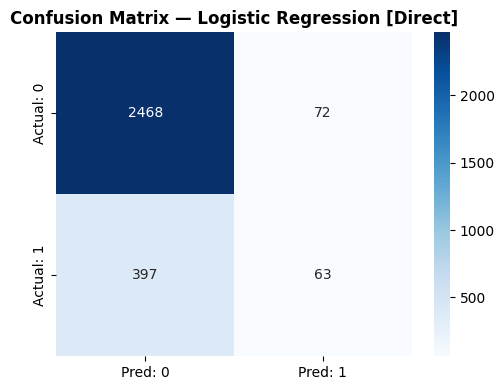

In [13]:
# Model 1: Logistic Regression
lr_dir = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr_dir = evaluate_model('Logistic Regression [Direct]',
                             lr_dir, X_train_dir, X_test_dir, y_train_dir, y_test_dir)


  Model : Random Forest [Direct]
  Accuracy  : 0.8470
  Precision : 0.5015
  Recall    : 0.3696
  F1-Score  : 0.4255

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.89      0.93      0.91      2540
       Churn       0.50      0.37      0.43       460

    accuracy                           0.85      3000
   macro avg       0.70      0.65      0.67      3000
weighted avg       0.83      0.85      0.84      3000



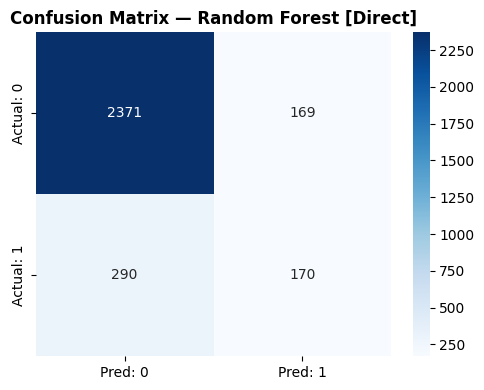

In [14]:
# Model 2: Random Forest
rf_dir = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
res_rf_dir = evaluate_model('Random Forest [Direct]',
                             rf_dir, X_train_dir, X_test_dir, y_train_dir, y_test_dir)


  Model : Voting Classifier (LR+KNN+RF) [Direct]
  Accuracy  : 0.8490
  Precision : 0.5248
  Recall    : 0.1609
  F1-Score  : 0.2463

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.92      2540
       Churn       0.52      0.16      0.25       460

    accuracy                           0.85      3000
   macro avg       0.69      0.57      0.58      3000
weighted avg       0.81      0.85      0.81      3000



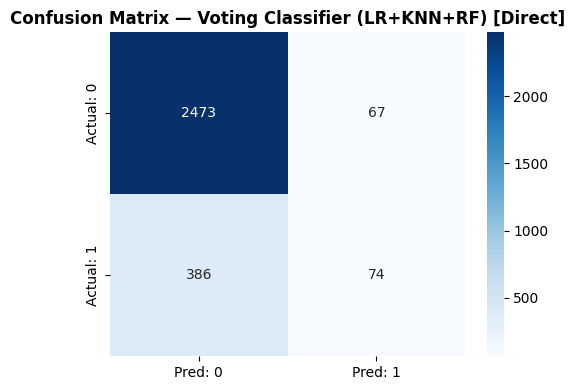

In [15]:
# Model 3: Voting Classifier (LR + KNN + RF)
estimators_dir = [
    ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=500)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('rf2', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1))
]
vc_dir = VotingClassifier(estimators=estimators_dir, voting='hard', n_jobs=-1)
res_vc_dir = evaluate_model('Voting Classifier (LR+KNN+RF) [Direct]',
                             vc_dir, X_train_dir, X_test_dir, y_train_dir, y_test_dir)

### 2.5 Ringkasan Performa — Direct Modeling

In [16]:
results_direct = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'}
    for r in [res_lr_dir, res_rf_dir, res_vc_dir]
])
print('\n📊 Ringkasan Performa — Direct Modeling')
print(results_direct.set_index('model').round(4).to_string())


📊 Ringkasan Performa — Direct Modeling
                                        accuracy  precision  recall      f1
model                                                                      
Logistic Regression [Direct]              0.8437     0.4667  0.1370  0.2118
Random Forest [Direct]                    0.8470     0.5015  0.3696  0.4255
Voting Classifier (LR+KNN+RF) [Direct]    0.8490     0.5248  0.1609  0.2463


---
# BAGIAN 3 — MODELING DENGAN PREPROCESSING
> **Tujuan:** Membersihkan data, encoding fitur kategorikal, menangani imbalance dengan SMOTE, lalu melatih ulang ketiga model.

### 3.1 Step 1 — Drop Kolom ID & Datetime

In [17]:
df_prep = df.copy()

# customer_id  : ID unik, tidak prediktif
# signup_date & last_purchase_date : tipe string datetime, butuh feature engineering
#   khusus yang di luar scope tugas ini, maka di-drop
df_prep.drop(columns=['customer_id', 'signup_date', 'last_purchase_date'], inplace=True)
print(f'Shape setelah drop ID & datetime: {df_prep.shape}')

Shape setelah drop ID & datetime: (15000, 27)


### 3.2 Step 2 — Handle Missing Value

In [18]:
# coupon_code (41% missing) → ubah jadi fitur biner has_coupon
# Alasan: info PUNYA/TIDAK kupon lebih bermakna dari kode kuponnya sendiri
df_prep['has_coupon'] = df_prep['coupon_code'].notna().astype(int)
df_prep.drop(columns=['coupon_code'], inplace=True)

# Numerik → imputasi median (robust terhadap outlier)
df_prep['age']                = df_prep['age'].fillna(df_prep['age'].median())
df_prep['total_spent']        = df_prep['total_spent'].fillna(df_prep['total_spent'].median())
df_prep['satisfaction_score'] = df_prep['satisfaction_score'].fillna(df_prep['satisfaction_score'].median())

# Kategorik → imputasi modus
df_prep['gender'] = df_prep['gender'].fillna(df_prep['gender'].mode()[0])

print(f'Missing value tersisa: {df_prep.isnull().sum().sum()}')

Missing value tersisa: 0


### 3.3 Step 3 — Handle Duplikasi

In [19]:
n_dup = df_prep.duplicated().sum()
df_prep.drop_duplicates(inplace=True)
print(f'Baris duplikat dihapus: {n_dup}')
print(f'Shape setelah de-duplikasi: {df_prep.shape}')

Baris duplikat dihapus: 0
Shape setelah de-duplikasi: (15000, 27)


### 3.4 Step 4 — Handle Outlier (IQR Capping)
> **Keputusan:** Gunakan capping (winsorizing) bukan deletion. Outlier pada data pelanggan (misal `total_spent` sangat tinggi) bisa jadi pelanggan VIP yang valid. Menghapus mereka justru menghilangkan informasi berharga. Capping menjaga nilai di batas wajar tanpa membuang data.

In [20]:
# Kolom yang di-cap: fitur numerik kontinyu saja
# Kolom biner (0/1) tidak perlu di-cap
binary_cols  = ['churn', 'is_premium_user', 'discount_used', 'refund_requested', 'has_coupon']
cap_cols     = df_prep.select_dtypes(include='number').columns.difference(binary_cols).tolist()

# Simpan data sebelum capping untuk visualisasi
df_before_cap = df_prep[cap_cols].copy()

n_outlier_total = 0
for col in cap_cols:
    Q1, Q3 = df_prep[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    n_outlier_total += n_out
    df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)

print(f'Total nilai di-cap (outlier): {n_outlier_total:,}')

Total nilai di-cap (outlier): 1,580


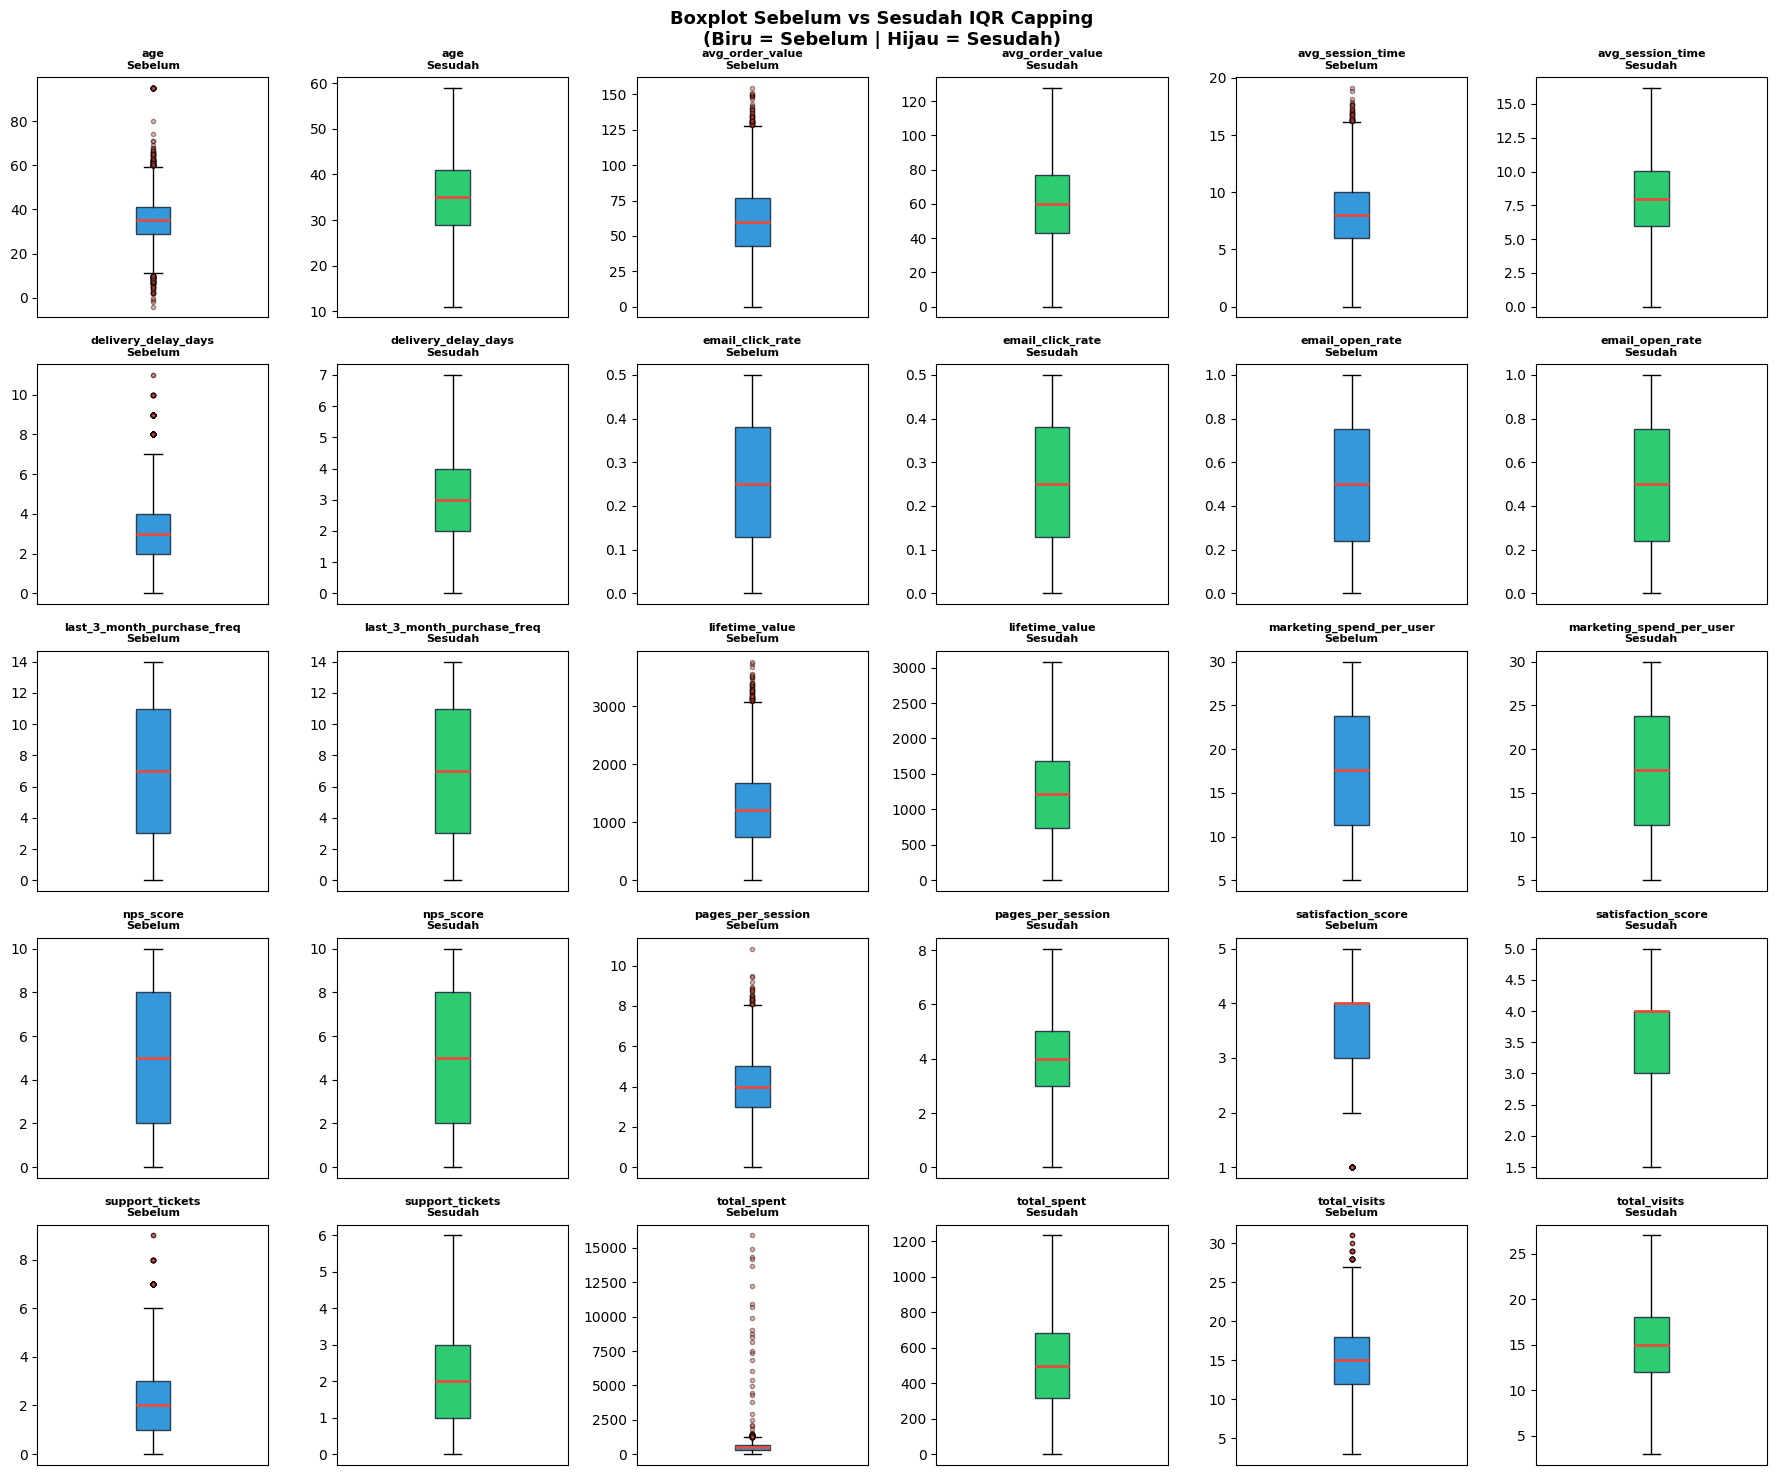

In [21]:
# Visualisasi Outlier — Sebelum vs Sesudah Capping
n_cols = 3
n_rows = (len(cap_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(18, n_rows * 3))

for i, col in enumerate(cap_cols):
    ax_before = axes[i // n_cols][( i % n_cols) * 2]
    ax_after  = axes[i // n_cols][(i % n_cols) * 2 + 1]

    ax_before.boxplot(df_before_cap[col], patch_artist=True,
                      boxprops=dict(facecolor='#3498db', color='#2c3e50'),
                      medianprops=dict(color='#e74c3c', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
    ax_before.set_title(f'{col}\nSebelum', fontsize=8, fontweight='bold')
    ax_before.set_xticks([])

    ax_after.boxplot(df_prep[col], patch_artist=True,
                     boxprops=dict(facecolor='#2ecc71', color='#2c3e50'),
                     medianprops=dict(color='#e74c3c', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
    ax_after.set_title(f'{col}\nSesudah', fontsize=8, fontweight='bold')
    ax_after.set_xticks([])

# Sembunyikan subplot kosong
total_subplots = n_rows * n_cols * 2
for j in range(len(cap_cols) * 2, total_subplots):
    fig.axes[j].set_visible(False)

plt.suptitle('Boxplot Sebelum vs Sesudah IQR Capping\n(Biru = Sebelum | Hijau = Sesudah)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Step 5 — Encoding Fitur Kategorikal
> **Keputusan:**
> - `subscription_type` (2 nilai: Annual/Monthly) → **LabelEncoder**, cukup jadi 0 dan 1
> - `gender` (3 nilai: Male/Female/Other) → **One-Hot Encoding**, agar model tidak mengasumsikan urutan ordinal
> - `country`, `acquisition_channel`, `device_type`, `payment_method` → **One-Hot Encoding**
> - `city` (kardinalitas tinggi) → **di-drop** untuk menghindari curse of dimensionality

In [22]:
# Label encode subscription_type (2 nilai)
le = LabelEncoder()
df_prep['subscription_type'] = le.fit_transform(df_prep['subscription_type'])
print(f'subscription_type mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# One-Hot Encoding untuk kolom nominal
ohe_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']
df_prep  = pd.get_dummies(df_prep, columns=ohe_cols, drop_first=True)

# Drop city
df_prep.drop(columns=['city'], inplace=True)

# Konversi kolom boolean hasil OHE ke int
bool_cols = df_prep.select_dtypes(include='bool').columns
df_prep[bool_cols] = df_prep[bool_cols].astype(int)

print(f'Shape setelah encoding: {df_prep.shape}')
print('✅ Preprocessing selesai.')

subscription_type mapping: {'Annual': np.int64(0), 'Monthly': np.int64(1)}
Shape setelah encoding: (15000, 37)
✅ Preprocessing selesai.


### 3.6 Train-Test Split (Proporsi Sama 80:20)

In [23]:
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_prep
)
print(f'Train: {X_train_p.shape} | Test: {X_test_p.shape}')

Train: (12000, 36) | Test: (3000, 36)


### 3.7 Scaling (Setelah Split)
> **Keputusan:** Scaling dilakukan **setelah** split untuk menghindari **data leakage** — jika sebelum split, statistik dari data test akan mempengaruhi scaler sehingga evaluasi menjadi terlalu optimistis. `StandardScaler` dipilih karena data sudah di-cap dari outlier.

In [24]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_p)   # fit HANYA pada train
X_test_sc  = scaler.transform(X_test_p)         # transform test pakai statistik train
print('✅ Scaling selesai (fit pada train, transform pada test).')

✅ Scaling selesai (fit pada train, transform pada test).


### 3.8 Tangani Class Imbalance — SMOTE
> **Keputusan:** SMOTE diterapkan **hanya pada data train**, bukan test. Data test harus mencerminkan distribusi dunia nyata. SMOTE menghasilkan sampel sintetis dari kelas minoritas berdasarkan KNN, lebih baik dari random oversampling biasa.

In [25]:
print(f'Sebelum SMOTE — Churn=0: {(y_train_p==0).sum():,} | Churn=1: {(y_train_p==1).sum():,}')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train_p)

print(f'Setelah SMOTE  — Churn=0: {(y_train_sm==0).sum():,} | Churn=1: {(y_train_sm==1).sum():,}')
print(f'Total data train setelah SMOTE: {len(y_train_sm):,}')

Sebelum SMOTE — Churn=0: 10,162 | Churn=1: 1,838
Setelah SMOTE  — Churn=0: 10,162 | Churn=1: 10,162
Total data train setelah SMOTE: 20,324


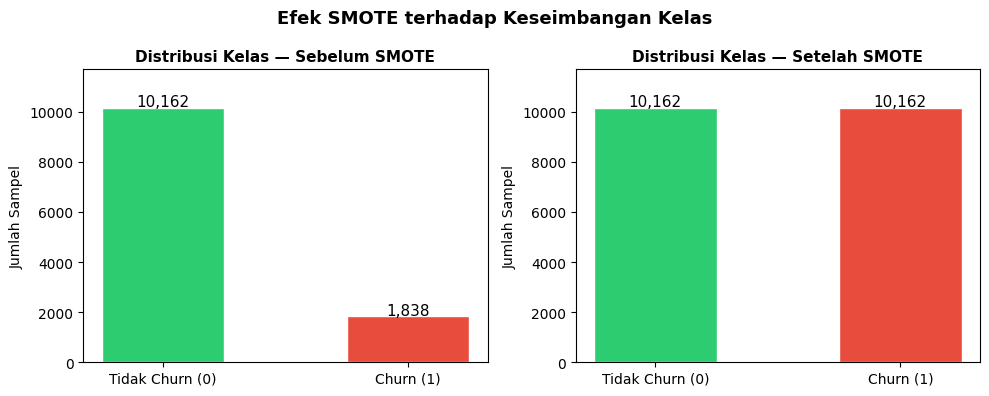

In [26]:
# Visualisasi Efek SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2ecc71', '#e74c3c']

before = pd.Series(y_train_p).value_counts().sort_index()
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], before.values,
            color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)
axes[0].set_title('Distribusi Kelas — Sebelum SMOTE', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, before.max() * 1.15)

after = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar(['Tidak Churn (0)', 'Churn (1)'], after.values,
            color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)
axes[1].set_title('Distribusi Kelas — Setelah SMOTE', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, after.max() * 1.15)

plt.suptitle('Efek SMOTE terhadap Keseimbangan Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.9 Latih & Evaluasi — Dengan Preprocessing


  Model : Logistic Regression [Preprocessing]
  Accuracy  : 0.7553
  Precision : 0.3539
  Recall    : 0.7217
  F1-Score  : 0.4750

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.76      0.84      2540
       Churn       0.35      0.72      0.47       460

    accuracy                           0.76      3000
   macro avg       0.65      0.74      0.66      3000
weighted avg       0.85      0.76      0.78      3000



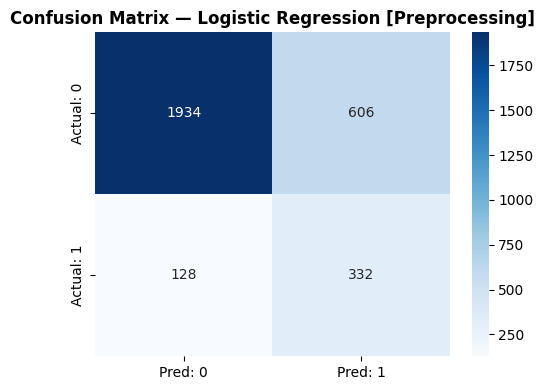

In [27]:
# Model 1: Logistic Regression
lr_prep = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr_prep = evaluate_model('Logistic Regression [Preprocessing]',
                              lr_prep, X_train_sm, X_test_sc, y_train_sm, y_test_p)


  Model : Random Forest [Preprocessing]
  Accuracy  : 0.8573
  Precision : 0.5267
  Recall    : 0.6870
  F1-Score  : 0.5962

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.89      0.91      2540
       Churn       0.53      0.69      0.60       460

    accuracy                           0.86      3000
   macro avg       0.73      0.79      0.75      3000
weighted avg       0.88      0.86      0.86      3000



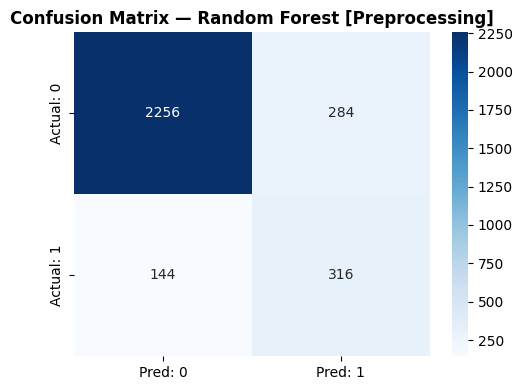

In [28]:
# Model 2: Random Forest
rf_prep = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
res_rf_prep = evaluate_model('Random Forest [Preprocessing]',
                              rf_prep, X_train_sm, X_test_sc, y_train_sm, y_test_p)


  Model : Voting Classifier (LR+SVM+KNN) [Preprocessing]
  Accuracy  : 0.8150
  Precision : 0.4279
  Recall    : 0.6130
  F1-Score  : 0.5040

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.92      0.85      0.89      2540
       Churn       0.43      0.61      0.50       460

    accuracy                           0.81      3000
   macro avg       0.68      0.73      0.70      3000
weighted avg       0.85      0.81      0.83      3000



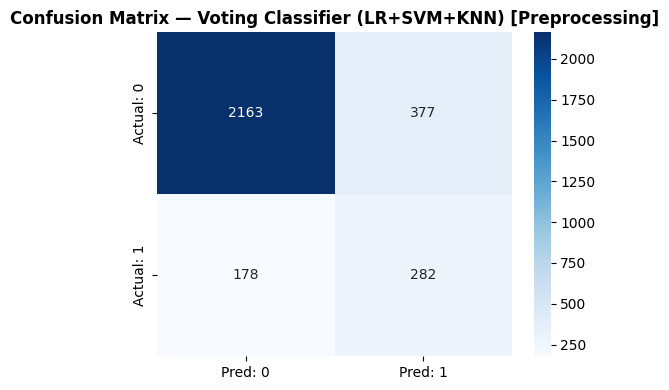

In [29]:
# Model 3: Voting Classifier (LR + SVM + KNN)
# Setelah scaling & SMOTE, SVM dan KNN bekerja optimal
estimators_prep = [
    ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=500)),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=7))
]
vc_prep = VotingClassifier(estimators=estimators_prep, voting='soft', n_jobs=-1)
res_vc_prep = evaluate_model('Voting Classifier (LR+SVM+KNN) [Preprocessing]',
                              vc_prep, X_train_sm, X_test_sc, y_train_sm, y_test_p)

### 3.10 Ringkasan Performa — Preprocessing

In [30]:
results_prep = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'}
    for r in [res_lr_prep, res_rf_prep, res_vc_prep]
])
print('\n📊 Ringkasan Performa — Preprocessing')
print(results_prep.set_index('model').round(4).to_string())


📊 Ringkasan Performa — Preprocessing
                                                accuracy  precision  recall      f1
model                                                                              
Logistic Regression [Preprocessing]               0.7553     0.3539  0.7217  0.4750
Random Forest [Preprocessing]                     0.8573     0.5267  0.6870  0.5962
Voting Classifier (LR+SVM+KNN) [Preprocessing]    0.8150     0.4279  0.6130  0.5040


---
# BAGIAN 4 — HYPERPARAMETER TUNING + FEATURE SELECTION
> **Tujuan:** Mengoptimalkan model terbaik dari skenario preprocessing menggunakan feature selection berbasis importance dan RandomizedSearchCV.

### 4.1 Feature Importance Analysis
> **Keputusan:** Random Forest digunakan sebagai estimator feature importance karena secara native menghasilkan skor berbasis Gini impurity. Fitur dengan importance sangat rendah (< 0.005) akan dieliminasi untuk mengurangi noise.

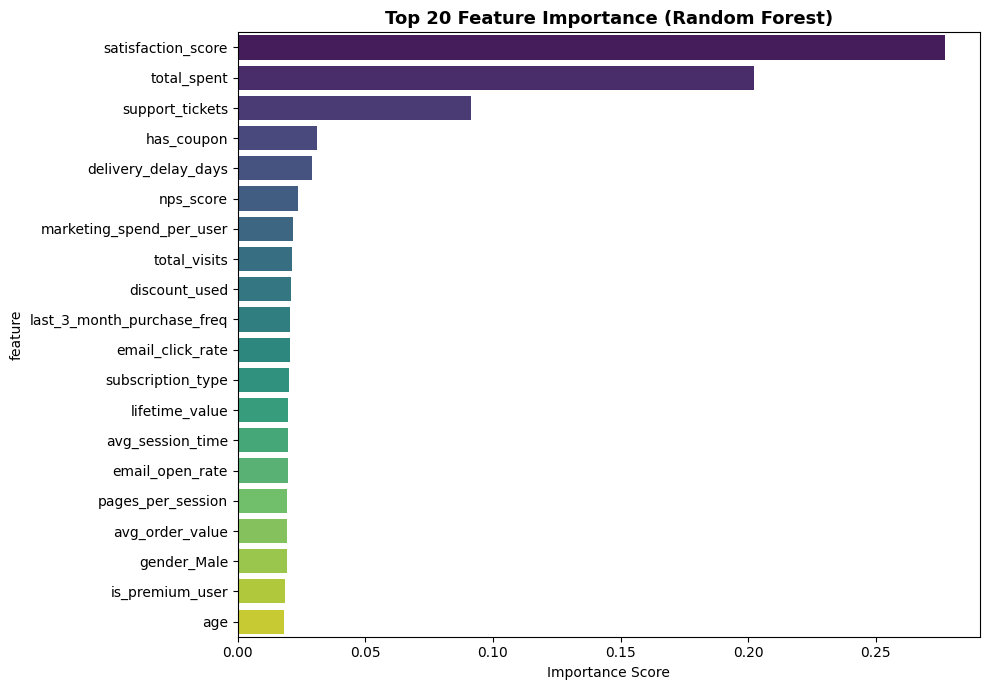

                   feature  importance
        satisfaction_score    0.276972
               total_spent    0.202127
           support_tickets    0.091303
                has_coupon    0.031169
       delivery_delay_days    0.029243
                 nps_score    0.023751
  marketing_spend_per_user    0.021645
              total_visits    0.021406
             discount_used    0.020701
last_3_month_purchase_freq    0.020393
          email_click_rate    0.020349
         subscription_type    0.020150
            lifetime_value    0.019812
          avg_session_time    0.019728
           email_open_rate    0.019702
         pages_per_session    0.019361
           avg_order_value    0.019354
               gender_Male    0.019114
           is_premium_user    0.018609
                       age    0.017923


In [31]:
feature_names = X_prep.columns.tolist()
importances   = res_rf_prep['fitted_model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Visualisasi Top 20
top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title(f'Top {top_n} Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.head(top_n).to_string(index=False))

### 4.2 Seleksi Fitur Berdasarkan Importance

In [32]:
IMPORTANCE_THRESHOLD = 0.005
selected_features = fi_df[fi_df['importance'] >= IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f'Fitur terpilih : {len(selected_features)} dari {len(feature_names)}')
print(f'Fitur dibuang  : {len(feature_names) - len(selected_features)}')

# Re-scale pada fitur terpilih saja (fit pada train, transform pada test)
X_train_sel = X_train_p[selected_features]
X_test_sel  = X_test_p[selected_features]

scaler_sel     = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

# SMOTE pada fitur terpilih
X_train_sel_sm, y_train_sel_sm = smote.fit_resample(X_train_sel_sc, y_train_p)
print(f'\nShape train setelah feature selection + SMOTE: {X_train_sel_sm.shape}')

Fitur terpilih : 22 dari 36
Fitur dibuang  : 14

Shape train setelah feature selection + SMOTE: (20324, 22)


### 4.3 Hyperparameter Tuning — Logistic Regression
> **Keputusan:** `RandomizedSearchCV` dipilih dibanding `GridSearchCV` karena lebih efisien pada ruang hyperparameter besar. `StratifiedKFold` (cv=5) menjaga proporsi kelas di setiap fold. Scoring menggunakan **F1** karena lebih seimbang antara precision dan recall — pada kasus churn, False Negative (gagal prediksi churn) lebih mahal dari False Positive.

In [33]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_param_grid = {
    'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear', 'saga'],
    'max_iter': [200, 500, 1000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_distributions=lr_param_grid,
    n_iter=30, scoring='f1', cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
lr_search.fit(X_train_sel_sm, y_train_sel_sm)

print(f'\n✅ Best Params LR : {lr_search.best_params_}')
print(f'   Best F1 (CV)   : {lr_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Params LR : {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'C': 0.001}
   Best F1 (CV)   : 0.7889



  Model : Logistic Regression [Tuned]
  Accuracy  : 0.7250
  Precision : 0.3293
  Recall    : 0.7652
  F1-Score  : 0.4604

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.72      0.82      2540
       Churn       0.33      0.77      0.46       460

    accuracy                           0.72      3000
   macro avg       0.64      0.74      0.64      3000
weighted avg       0.85      0.72      0.76      3000



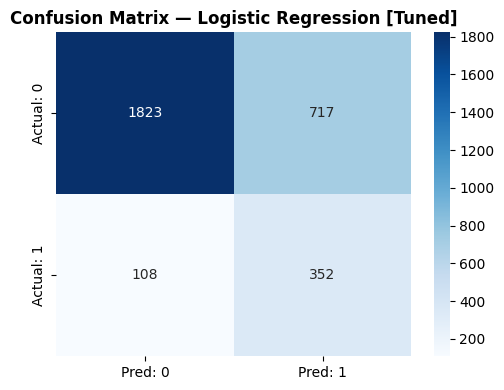

In [34]:
res_lr_tuned = evaluate_model('Logistic Regression [Tuned]',
                               lr_search.best_estimator_,
                               X_train_sel_sm, X_test_sel_sc,
                               y_train_sel_sm, y_test_p, fit=False)

### 4.4 Hyperparameter Tuning — Random Forest

In [35]:
rf_param_grid = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=15, scoring='f1', cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_sel_sm, y_train_sel_sm)

print(f'\n✅ Best Params RF : {rf_search.best_params_}')
print(f'   Best F1 (CV)   : {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Best Params RF : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None}
   Best F1 (CV)   : 0.9226



  Model : Random Forest [Tuned]
  Accuracy  : 0.8557
  Precision : 0.5192
  Recall    : 0.7935
  F1-Score  : 0.6277

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.96      0.87      0.91      2540
       Churn       0.52      0.79      0.63       460

    accuracy                           0.86      3000
   macro avg       0.74      0.83      0.77      3000
weighted avg       0.89      0.86      0.87      3000



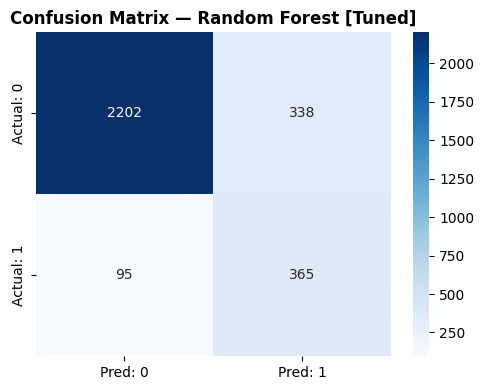

In [41]:
res_rf_tuned = evaluate_model('Random Forest [Tuned]',
                               rf_search.best_estimator_,
                               X_train_sel_sm, X_test_sel_sc,
                               y_train_sel_sm, y_test_p, fit=False)

### 4.5 Hyperparameter Tuning — Voting Classifier
> **Keputusan:** Pada VotingClassifier, tuning dilakukan pada komponen internal menggunakan format `estimator__param` agar setiap sub-model bisa dioptimalkan sekaligus dalam satu pencarian.

In [42]:
vc_base = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=500)),
        ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

vc_param_grid = {
    'lr__C'           : [0.1, 1, 10],
    'svm__C'          : [0.1, 1, 10],
    'svm__kernel'     : ['rbf', 'linear'],
    'knn__n_neighbors': [5, 7, 11]
}

vc_search = RandomizedSearchCV(
    vc_base,
    param_distributions=vc_param_grid,
    n_iter=15, scoring='f1', cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
vc_search.fit(X_train_sel_sm, y_train_sel_sm)

print(f'\n✅ Best Params VC : {vc_search.best_params_}')
print(f'   Best F1 (CV)   : {vc_search.best_score_:.4f}')

Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Best Params VC : {'svm__kernel': 'rbf', 'svm__C': 10, 'lr__C': 10, 'knn__n_neighbors': 7}
   Best F1 (CV)   : 0.9297



  Model : Voting Classifier [Tuned]
  Accuracy  : 0.8230
  Precision : 0.4385
  Recall    : 0.5500
  F1-Score  : 0.4879

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.91      0.87      0.89      2540
       Churn       0.44      0.55      0.49       460

    accuracy                           0.82      3000
   macro avg       0.68      0.71      0.69      3000
weighted avg       0.84      0.82      0.83      3000



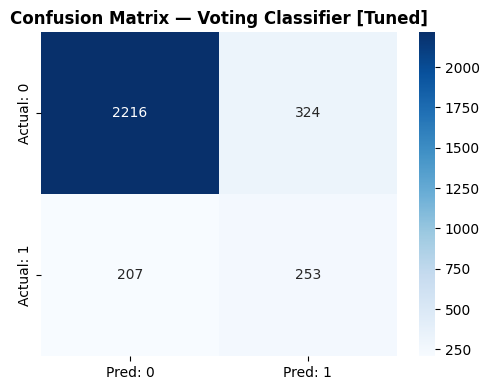

In [43]:
res_vc_tuned = evaluate_model('Voting Classifier [Tuned]',
                               vc_search.best_estimator_,
                               X_train_sel_sm, X_test_sel_sc,
                               y_train_sel_sm, y_test_p, fit=False)

### 4.6 Perbandingan Semua 9 Model


📊 RINGKASAN SEMUA 9 MODEL
                                         model  accuracy  precision  recall     f1
                  Logistic Regression [Direct]    0.8437     0.4667  0.1370 0.2118
                        Random Forest [Direct]    0.8470     0.5015  0.3696 0.4255
        Voting Classifier (LR+KNN+RF) [Direct]    0.8490     0.5248  0.1609 0.2463
           Logistic Regression [Preprocessing]    0.7553     0.3539  0.7217 0.4750
                 Random Forest [Preprocessing]    0.8573     0.5267  0.6870 0.5962
Voting Classifier (LR+SVM+KNN) [Preprocessing]    0.8150     0.4279  0.6130 0.5040
                   Logistic Regression [Tuned]    0.7250     0.3293  0.7652 0.4604
                         Random Forest [Tuned]    0.8557     0.5192  0.7935 0.6277
                     Voting Classifier [Tuned]    0.8230     0.4385  0.5500 0.4879


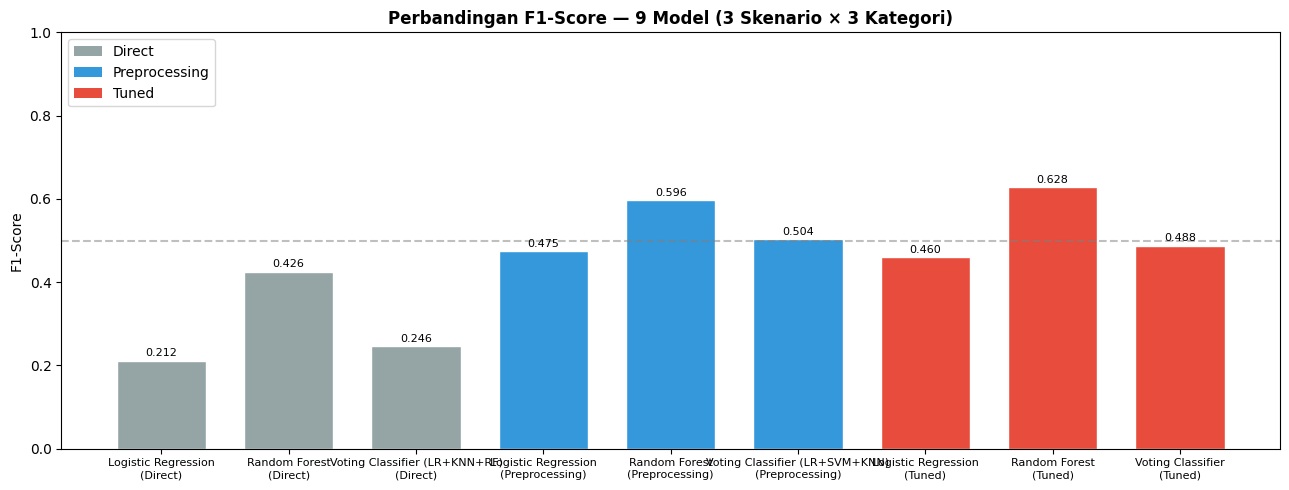

In [44]:
all_results = [res_lr_dir, res_rf_dir, res_vc_dir,
               res_lr_prep, res_rf_prep, res_vc_prep,
               res_lr_tuned, res_rf_tuned, res_vc_tuned]

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'}
    for r in all_results
])
df_results['skenario']   = ['Direct']*3 + ['Preprocessing']*3 + ['Tuned']*3
df_results['model_type'] = ['LR', 'RF', 'VC'] * 3

print('\n📊 RINGKASAN SEMUA 9 MODEL')
print(df_results[['model','accuracy','precision','recall','f1']].round(4).to_string(index=False))

# Visualisasi
colors_skenario = {'Direct': '#95a5a6', 'Preprocessing': '#3498db', 'Tuned': '#e74c3c'}
fig, ax = plt.subplots(figsize=(13, 5))
for i, row in df_results.iterrows():
    ax.bar(i, row['f1'], color=colors_skenario[row['skenario']], edgecolor='white', width=0.7)
    ax.text(i, row['f1'] + 0.005, f"{row['f1']:.3f}", ha='center', va='bottom', fontsize=8)

labels = [r['model'].replace(' [Direct]','').replace(' [Preprocessing]','').replace(' [Tuned]','')
          + f"\n({df_results.iloc[i]['skenario']})" for i, r in enumerate(all_results)]
ax.set_xticks(range(9))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score — 9 Model (3 Skenario × 3 Kategori)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in colors_skenario.items()]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

### 4.7 Identifikasi & Simpan Model Terbaik

In [45]:
best_idx       = df_results['f1'].idxmax()
best_row       = df_results.loc[best_idx]
best_fitted    = all_results[best_idx]['fitted_model']

print('🏆 MODEL TERBAIK:')
print(f'   Nama      : {best_row["model"]}')
print(f'   Skenario  : {best_row["skenario"]}')
print(f'   Accuracy  : {best_row["accuracy"]:.4f}')
print(f'   Precision : {best_row["precision"]:.4f}')
print(f'   Recall    : {best_row["recall"]:.4f}')
print(f'   F1-Score  : {best_row["f1"]:.4f}')

# Simpan model, scaler, dan daftar fitur terpilih
joblib.dump(best_fitted,       'best_model.pkl')
joblib.dump(scaler_sel,        'scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')

print('\n✅ File tersimpan:')
print('   - best_model.pkl')
print('   - scaler.pkl')
print('   - selected_features.pkl')

🏆 MODEL TERBAIK:
   Nama      : Random Forest [Tuned]
   Skenario  : Tuned
   Accuracy  : 0.8557
   Precision : 0.5192
   Recall    : 0.7935
   F1-Score  : 0.6277

✅ File tersimpan:
   - best_model.pkl
   - scaler.pkl
   - selected_features.pkl


---
## ✅ Summary Keputusan

| Aspek | Keputusan | Alasan |
|---|---|---|
| Train-Test Split | 80:20, stratified | Proporsi standar; stratify jaga distribusi kelas |
| Missing Value | Median/mode + `has_coupon` biner | Robust outlier; kupon lebih informatif sebagai biner |
| Outlier | IQR Capping | Preservasi data pelanggan VIP |
| Encoding | LabelEncoder (2 nilai) + OHE (>2 nilai) | Hindari ordinal bias pada gender & nominal lain |
| Drop Fitur | `city` (kardinalitas tinggi), ID, datetime | Curse of dimensionality |
| Scaling | StandardScaler setelah split | Cegah data leakage |
| Imbalance | SMOTE hanya pada train | Test tetap mencerminkan distribusi nyata |
| Feature Selection | Importance ≥ 0.005 | Kurangi noise tanpa buang sinyal penting |
| Tuning | RandomizedSearchCV + StratifiedKFold(5) | Efisien; CV terjaga proporsi kelas |
| Scoring | F1-Score | FN lebih mahal di kasus churn |

---
*Next step → Deployment ke Streamlit Cloud*

In [60]:
!pip install streamlit --ignore-installed blinker

  Using cached streamlit-1.58.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached watchdog-6.0.0-py3-none-manylinux2014_x86_64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
Using cached streamlit-1.58.0-py3-none-any.whl (9.2 MB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.6/797.6 kB 23.0 MB/s  0:00:00
Using cached cachetools-7.1.4-py3-none-any.whl (16 kB)
Using cached gitpython-3.1.50-py3-none-any.whl (212 kB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 181.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [62]:
!pip show streamlit

Name: streamlit
Version: 1.58.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: 
Author-email: Snowflake Inc <hello@streamlit.io>
License-Expression: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: altair, anyio, blinker, cachetools, click, gitpython, httptools, itsdangerous, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, python-multipart, requests, starlette, tenacity, toml, typing-extensions, uvicorn, watchdog, websockets
Required-by: 


In [61]:
import streamlit as st

In [69]:
# ============================
# Load Model
# ============================

model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
selected_features = joblib.load("selected_features.pkl")

# ============================
# Konfigurasi Halaman
# ============================

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)

# ============================
# Header
# ============================

st.title("📊 Customer Churn Prediction")

st.markdown("""
Aplikasi ini digunakan untuk memprediksi apakah seorang pelanggan akan
**Churn** atau **Tidak Churn** berdasarkan data pelanggan.
""")

st.divider()

# ============================
# Sidebar
# ============================

st.sidebar.header("Informasi")

st.sidebar.write("""
Model Machine Learning

Dataset : Sales Marketing Customer

Target :
- 0 = Tidak Churn
- 1 = Churn
""")

# ============================
# Input Data
# ============================

st.header("Input Data Customer")

satisfaction_score = st.slider("Satisfaction Score",1,10,5)

total_spent = st.number_input("Total Spent",0.0)

support_tickets = st.number_input("Support Tickets",0)

has_coupon = st.selectbox(
    "Has Coupon",
    [0,1]
)

delivery_delay_days = st.number_input(
    "Delivery Delay Days",
    0
)

nps_score = st.slider(
    "NPS Score",
    0,
    10,
    5
)

marketing_spend_per_user = st.number_input(
    "Marketing Spend Per User",
    0.0
)

total_visits = st.number_input(
    "Total Visits",
    0
)

discount_used = st.number_input(
    "Discount Used",
    0.0
)

last_3_month_purchase_freq = st.number_input(
    "Purchase Frequency (3 Months)",
    0
)

email_click_rate = st.slider(
    "Email Click Rate",
    0.0,
    1.0,
    0.5
)

subscription = st.selectbox(
    "Subscription Type",
    ["Basic", "Premium", "Standard"]
)

mapping = {
    "Basic": 0,
    "Premium": 1,
    "Standard": 2
}

subscription_type = mapping[subscription]

lifetime_value = st.number_input(
    "Lifetime Value",
    0.0
)

avg_session_time = st.number_input(
    "Average Session Time",
    0.0
)

email_open_rate = st.slider(
    "Email Open Rate",
    0.0,
    1.0,
    0.5
)

pages_per_session = st.number_input(
    "Pages Per Session",
    0.0
)

avg_order_value = st.number_input(
    "Average Order Value",
    0.0
)

gender = st.selectbox(
    "Gender",
    ["Female","Male"]
)

is_premium_user = st.selectbox(
    "Premium User",
    [0,1]
)

age = st.number_input(
    "Age",
    18,
    100,
    25
)

device = st.selectbox(
    "Device Type",
    ["Desktop","Tablet","Mobile"]
)

# ============================
# Tombol Prediksi
# ============================

if st.button("Predict"):

    gender_Male = 1 if gender=="Male" else 0

    device_type_Tablet = 1 if device=="Tablet" else 0

    device_type_Mobile = 1 if device=="Mobile" else 0

    data = pd.DataFrame({

        "satisfaction_score":[satisfaction_score],
        "total_spent":[total_spent],
        "support_tickets":[support_tickets],
        "has_coupon":[has_coupon],
        "delivery_delay_days":[delivery_delay_days],
        "nps_score":[nps_score],
        "marketing_spend_per_user":[marketing_spend_per_user],
        "total_visits":[total_visits],
        "discount_used":[discount_used],
        "last_3_month_purchase_freq":[last_3_month_purchase_freq],
        "email_click_rate":[email_click_rate],
        "subscription_type":[subscription_type],
        "lifetime_value":[lifetime_value],
        "avg_session_time":[avg_session_time],
        "email_open_rate":[email_open_rate],
        "pages_per_session":[pages_per_session],
        "avg_order_value":[avg_order_value],
        "gender_Male":[gender_Male],
        "is_premium_user":[is_premium_user],
        "age":[age],
        "device_type_Tablet":[device_type_Tablet],
        "device_type_Mobile":[device_type_Mobile]

    })

    data = data[selected_features]

    data_scaled = scaler.transform(data)

    prediction = model.predict(data_scaled)[0]

    probability = model.predict_proba(data_scaled)[0]

    st.subheader("Prediction Result")

    if prediction==1:
        st.error("⚠ Customer Diprediksi Churn")

    else:
        st.success("✅ Customer Diprediksi Tidak Churn")

    st.metric(
        "Probabilitas Churn",
        f"{probability[1]*100:.2f}%"
    )

2026-06-27 17:38:19.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 17:38:19.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [71]:
selected_features = joblib.load("selected_features.pkl")

print(selected_features)

['satisfaction_score', 'total_spent', 'support_tickets', 'has_coupon', 'delivery_delay_days', 'nps_score', 'marketing_spend_per_user', 'total_visits', 'discount_used', 'last_3_month_purchase_freq', 'email_click_rate', 'subscription_type', 'lifetime_value', 'avg_session_time', 'email_open_rate', 'pages_per_session', 'avg_order_value', 'gender_Male', 'is_premium_user', 'age', 'device_type_Tablet', 'device_type_Mobile']


In [72]:
%%writefile app.py

Writing app.py


In [73]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://good-roses-laugh.loca.lt


In [ ]:
!cat /content/log.txt